In [1]:
# Importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Supprimer les warning
import warnings
warnings.filterwarnings("ignore")

### <font color = 'teal'>Importer et Lire les données<font>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# importer les données
# importer les données
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/Telephone_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Afficher les données
df.head()

,prix,adresse,marque,dim_ecr,ram,stockage,etat
0,580000,Guediawaye,iPhone,6.0,8,128,D'occasion
1,250000,Mermoz,iPhone,6.0,4,128,D'occasion
2,80000,Médina,iPhone,5.0,5,128,D'occasion
3,290000,Plateau,Samsung,6.0,8,256,D'occasion
4,250000,Mermoz,Samsung,6.0,8,256,D'occasion


#### <font color = "bisque">Concernant les données<font>
Les données viennent de la page [coinafrique](http://sn.coinafrique.com/). L'objectif de la classification est de prédire si un portable est d'occasion, neuf, reconditionné ou venant en partant des caractéristiques suivant:
* Prix
* Adresse de vente
* Marque
* Dimension de l'écran
* Nombre de ram
* Stockage

In [7]:
# dimension des données
df.shape

(3253, 7)

In [ ]:
# infos des données


### <font color = 'gold'>Exploration des données<font>

##### <font color = 'bisque'>Séléction des variables

In [8]:
# sélection des variables catégorielles en utilisant select_dtypes
cat_data = df.select_dtypes(include = 'object')
cat_data.head()

,adresse,marque,etat
0,Guediawaye,iPhone,D'occasion
1,Mermoz,iPhone,D'occasion
2,Médina,iPhone,D'occasion
3,Plateau,Samsung,D'occasion
4,Mermoz,Samsung,D'occasion


In [9]:
# sélection des variables quantitatives en utilisant select_dtypes
quant_data = df.select_dtypes(include = 'number')
quant_data.head()

,prix,dim_ecr,ram,stockage
0,580000,6.0,8,128
1,250000,6.0,4,128
2,80000,5.0,5,128
3,290000,6.0,8,256
4,250000,6.0,8,256


##### <font color = 'bisque'> Exploration des variables catégorielles

In [11]:
# décrire les variables catégorielles
cat_data.describe().T


,count,unique,top,freq
adresse,3253,43,Plateau,415
marque,3253,28,iPhone,1571
etat,3253,4,Réconditionné,1053


In [14]:
# fonction de countplot
import plotly.express as px
def countplot_func(col):
  val = df[col].value_counts()
  # plt.figure(figsize=(25,3))
  fig = px.bar(x=val.index, y=val.values, color = val.index.astype(str), text_auto=True)
  fig.show()

In [15]:
# Countplots de toutes les variables
for col in cat_data.columns:
  countplot_func(col)

##### <font color = 'bisque'> Exploration des variables quantitatives

In [16]:
# décrire les variables quantitatives
quant_data.describe().T

,count,mean,std,min,25%,50%,75%,max
prix,3253.0,360830.307101,215801.003089,1.0,237043.0,362043.0,462044.0,3335000.0
dim_ecr,3253.0,6.510913,3.466092,0.0,6.0,6.0,7.0,75.0
ram,3253.0,16.377498,20.291301,1.0,11.0,12.0,14.0,512.0
stockage,3253.0,193.514294,169.625904,1.0,128.0,158.0,256.0,5120.0


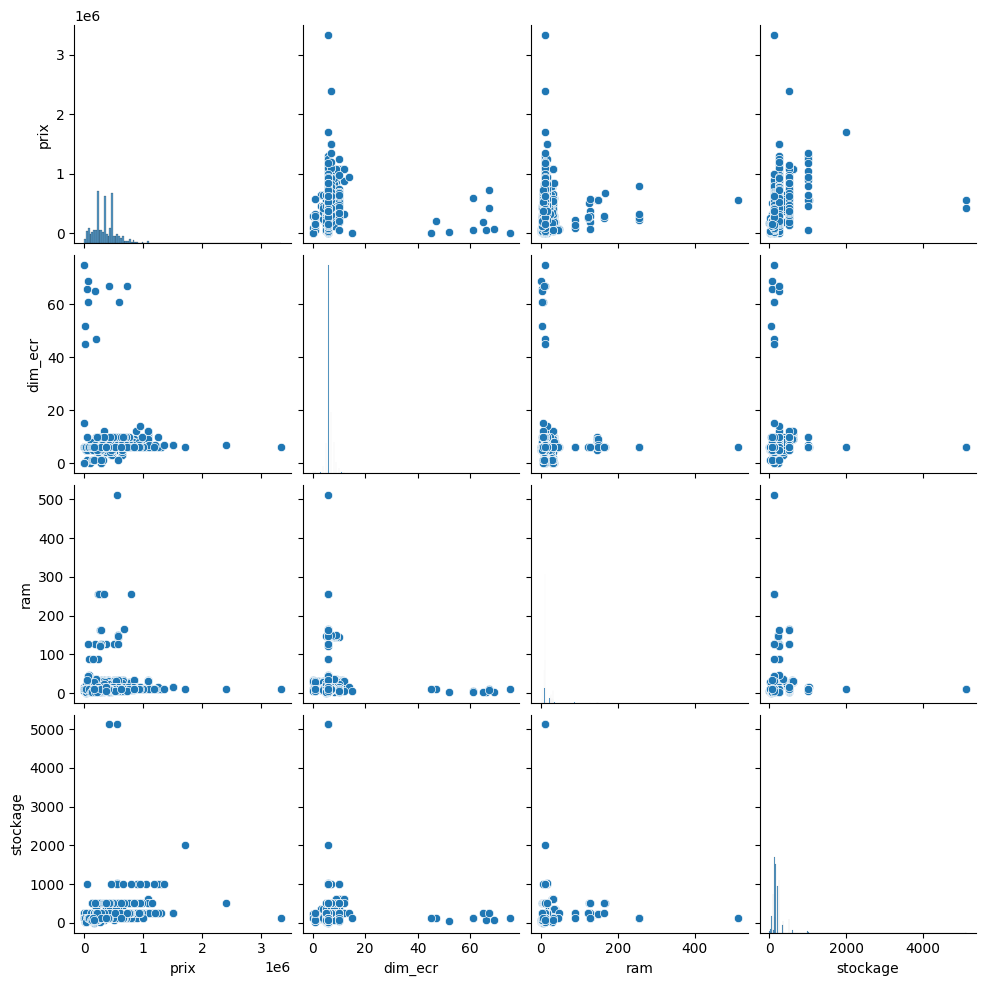

In [17]:
# pairplot
sns.pairplot(quant_data)
plt.show()

In [19]:
# matrice de corrélation
quant_data.corr()

,prix,dim_ecr,ram,stockage
prix,1.000000,0.040199,0.159535,0.359586
dim_ecr,0.040199,1.000000,0.024216,0.027186
ram,0.159535,0.024216,1.000000,0.095711
stockage,0.359586,0.027186,0.095711,1.000000


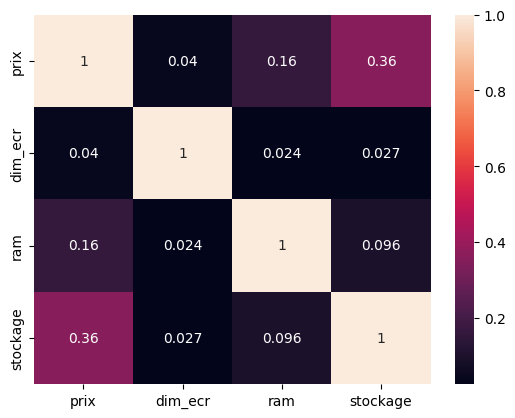

In [18]:
# matrice heatmap
sns.heatmap(quant_data.corr(), annot= True)
plt.show()

In [20]:
# fonction boxplots
def boxplot_func(col):
  plt.figure(figsize=(25,3))
  sns.boxplot(x=df[col])
  plt.show()

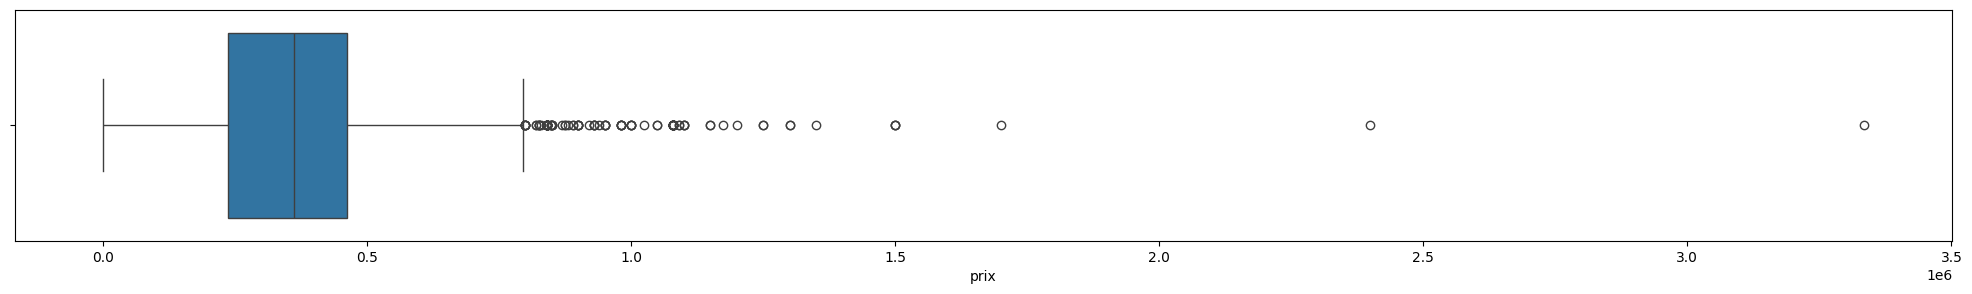

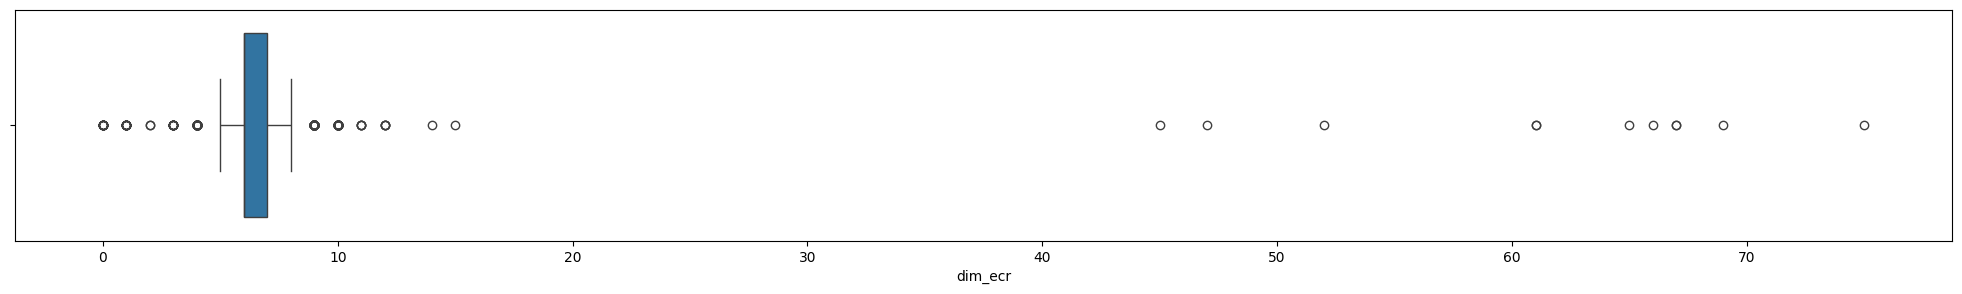

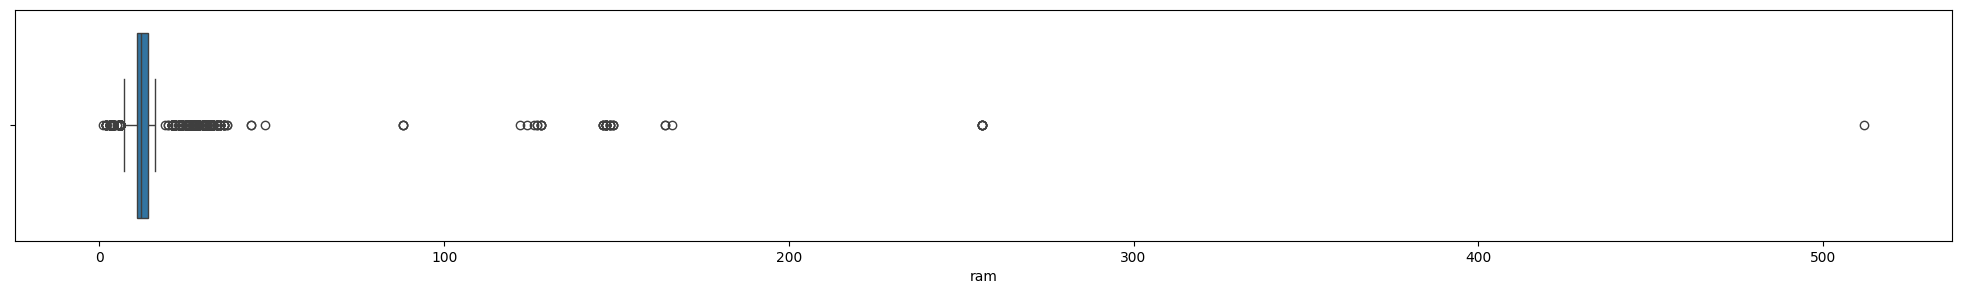

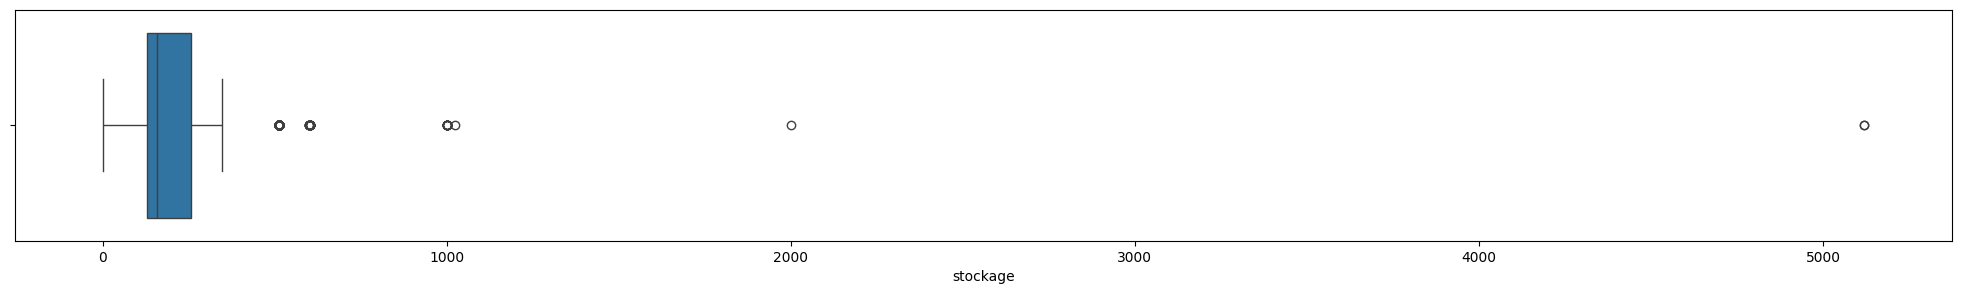

In [21]:
# boxplots des toutes les variables quantitatives
for col in quant_data.columns:
  boxplot_func(col)

### <font color = 'gold'>Preparation des données<font>



##### <font color = 'bisque'> Preparation des variables catégorielles

In [22]:
import joblib as jb
# Enregistrer les valeurs uniques des variables catégorielles dans un objet joblib
uniques = [] # [list_adresse, list_marque, list_etat]
for col in cat_data.columns:
  uniques.append(list(np.unique(df[col])))

In [23]:
# faire un dumping de la liste des valeurs uniques
jb.dump(uniques, '/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/uniques.joblib')

['/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/uniques.joblib']

In [24]:
# Encoder les variables catégorielles
from sklearn.preprocessing import LabelEncoder

encoder0 = LabelEncoder() # objet encoder pour la variable adresse
encoder1 = LabelEncoder() # objet encoder pour la variable marque
encoder2 = LabelEncoder() # objet encoder pour la variable etat
encoders = [encoder0, encoder1, encoder2]
for i in range(len(cat_data.columns)):
  encoders[i].fit(df[cat_data.columns[i]]) # le modèle prend le temps de reconnaitre les classes
  df[cat_data.columns[i]] = encoders[i].transform(df[cat_data.columns[i]]) # encoder les valeurs

In [26]:
#address, marque, etat sont encodées
df.head()

,prix,adresse,marque,dim_ecr,ram,stockage,etat
0,580000,13,27,6.0,8,128,0
1,250000,22,27,6.0,4,128,0
2,80000,23,27,5.0,5,128,0
3,290000,32,19,6.0,8,256,0
4,250000,22,19,6.0,8,256,0


In [27]:
# faire un dumping (télécharger) de la liste des encodeurs
jb.dump(encoders, '/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/encoders.joblib')

['/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/encoders.joblib']

##### <font color = 'bisque'> Preparation des quantitatives

In [28]:
from sklearn.impute import KNNImputer

# fonction d'imputation des valeurs aberrantes
def impute_func(df, col, n_neighbors=3):
    # 2. Détection des outliers (Méthode IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    min_value = Q1 - 1.5 * IQR
    max_value = Q3 + 1.5 * IQR

    # Les valeurs hors bornes deviennent des valeurs manquantes pour le KNNImputer
    df.loc[(df[col] < min_value) | (df[col] > max_value), col] = np.nan
    # n_neighbors : nombre de voisins pour calculer la moyenne de remplacement
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df[:] = imputer.fit_transform(df)

In [29]:
# Application du traitement
for col in quant_data.columns:
  impute_func(df,col)

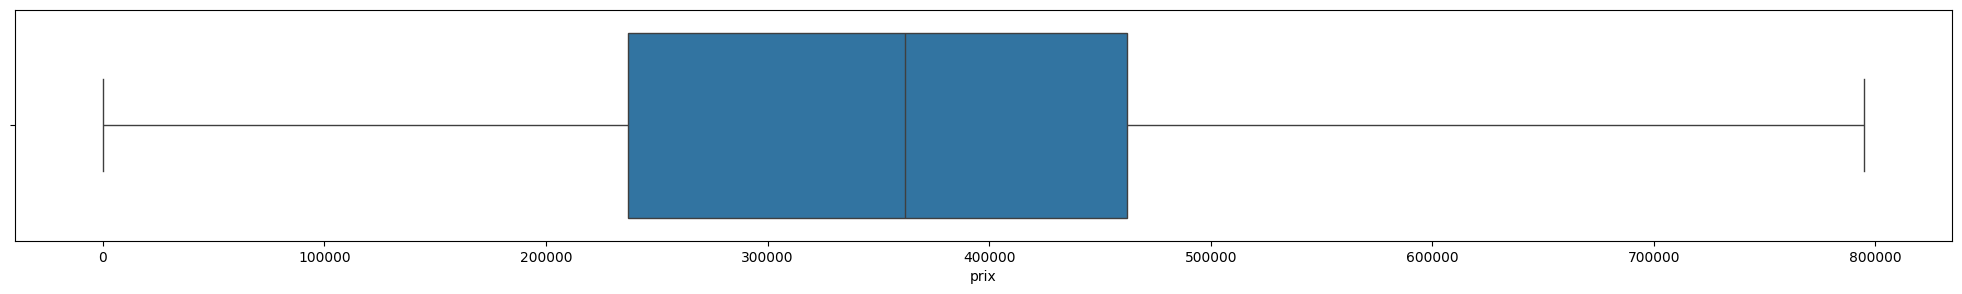

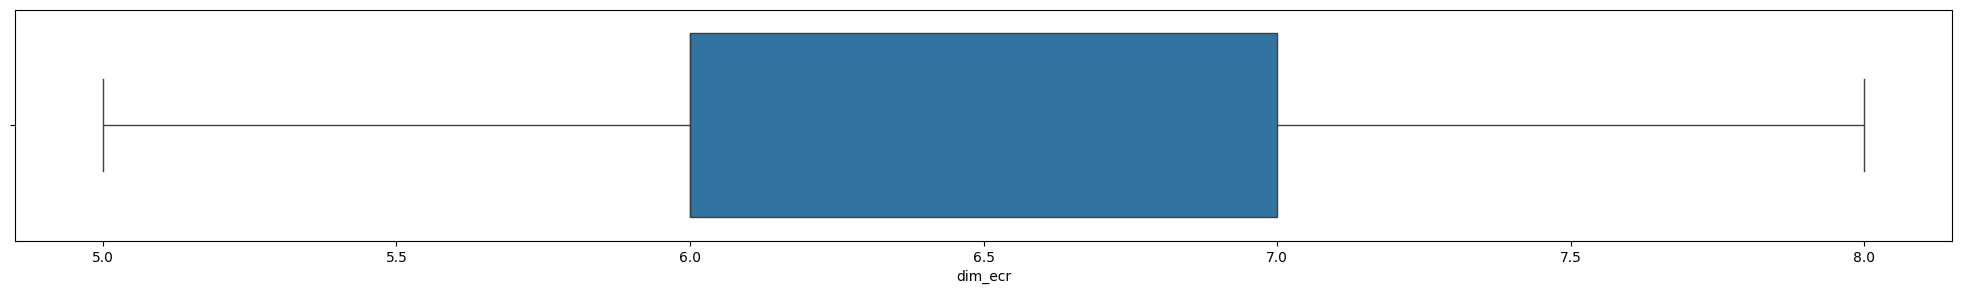

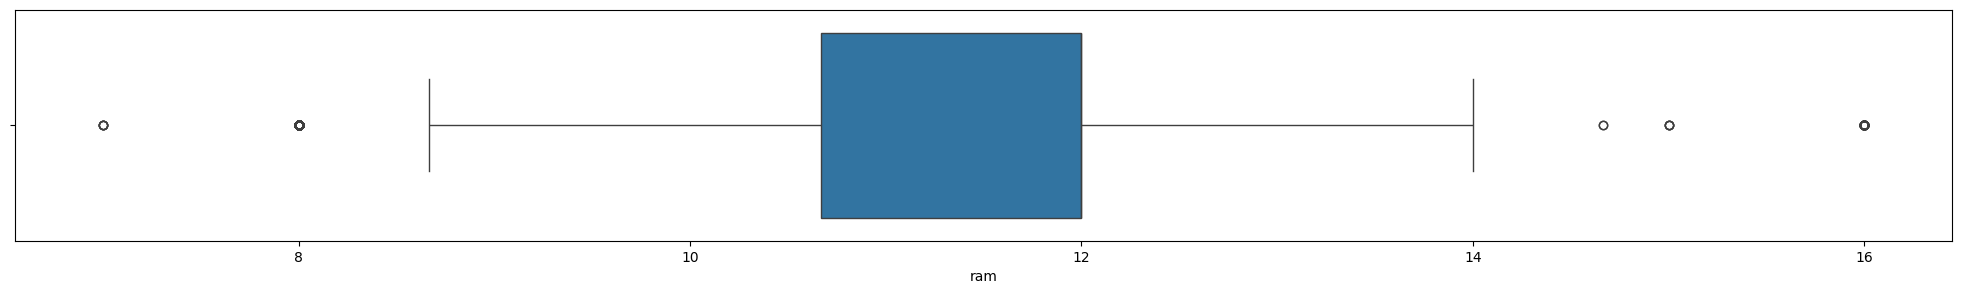

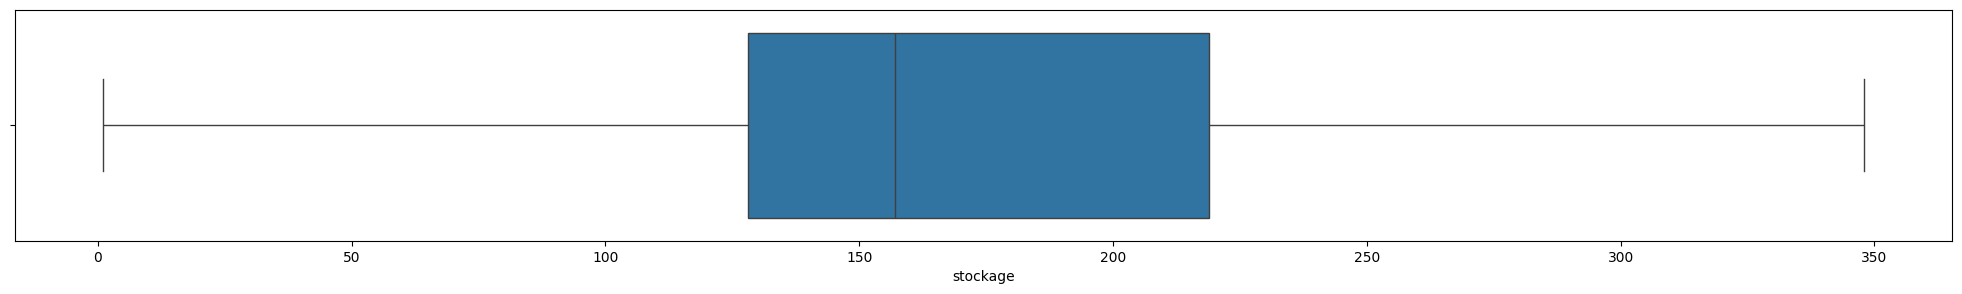

In [31]:
# réafficher les boxplots
for col in quant_data.columns:
  boxplot_func(col)

In [ ]:
# calculer la valeur minimale et valeur maximale
Q1 = df['ram'].quantile(0.25)
Q3 = df['ram'].quantile(0.75)
IQR = Q3 - Q1
min_value = Q1 - 1.5 * IQR
max_value = Q3 + 1.5 * IQR
# supprimer les nouvelles valeurs abérantes de la varibel ram
indexes = list(df.loc[(df['ram'] < min_value) | (df['ram'] > max_value), 'ram'].index)
df.drop(indexes, axis = 0, inplace =True)

##### <font color = 'bisque'> Fractionnement et normalisation

In [33]:
# Fractionner les données en variables prédicteurs (x) et variable cibel(y)
x = df.iloc[:,:-1].values # variables d'entrées
y = df.iloc[:, -1].values # variable de sortie


In [34]:
# importer StandardScaler
from sklearn.preprocessing import StandardScaler
# Instancier StandardScaler
scaler = StandardScaler()
scaler.fit(x) # calcul de la moyenne et de l'écart type
x = scaler.transform(x) # normalisation

In [35]:
# faire un dumping (télécharger) du normaliseur
jb.dump(scaler, '/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/scaler.joblib')

['/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/scaler.joblib']

In [36]:
# splitter les données en train, val et test
# train (80%), val(10%) et test(10%)
#train : données d'entrainement, val: données utiliser pour évaluer chaque modèle et test: données pour tester le modèle le plus performant
from sklearn.model_selection import train_test_split
x_train,x_vt, y_train, y_vt = train_test_split(x, y, train_size = 0.8 ,random_state = 42) # 80% / 20%
x_val,x_test, y_val, y_test = train_test_split(x_vt, y_vt, train_size = 0.5, random_state = 42) # 10% / 10%

In [37]:
# dimension des données train
x_train.shape, y_train.shape

((2248, 6), (2248,))

In [38]:
# dimension des données de validation
x_val.shape, y_val.shape

((281, 6), (281,))

In [39]:
# dimension des données test
x_test.shape, y_test.shape

((282, 6), (282,))

### <font color = 'teal'>Random Forest<font>

In [40]:
# Recherche des paramètres optimaux pour le Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# dictionnaire des  params
params = param_grid = {
    'n_estimators': list(np.arange(10,100,10)),
    'max_depth' : list(np.arange(3,15)),
    'criterion' :['gini', 'entropy']
}
# instantier le modèle Random Forest
rf = RandomForestClassifier()
# instantier le modèle gridsearch
grid = GridSearchCV(estimator=rf, param_grid=params, cv= 5)
# entrainer le modèle
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [46]:
# Afficher les paramètres optimaux
best_params = grid.best_params_
best_params

{'criterion': 'gini', 'max_depth': np.int64(10), 'n_estimators': np.int64(60)}

In [45]:
# Entrainer Random Forest en utilisant les paramètres optimaux
rf_model = RandomForestClassifier(**best_params)
rf_model.fit(x_train, y_train)

RandomForestClassifier(max_depth=np.int64(10), n_estimators=np.int64(60))

##### <font color ='bisque'>Evaluation du Random Forest<font>

In [48]:
# Accuracy et F1 score du modèle sur les données de validation
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
def evaluation(model):
  y_pred = model.predict(x_val)
  acc = accuracy_score(y_val, y_pred)
  f1 = f1_score(y_val, y_pred, average='micro')
  prec = precision_score(y_val, y_pred, average='micro')
  rec = recall_score(y_val, y_pred, average='micro')
  return acc, f1, prec, rec

In [50]:
# Afficher les métriques
acc_rf, f1_rf, prec_rf, rec_rf = evaluation(rf_model)
print(f"Accuracy : {acc_rf:.2f}-- F1 score : {f1_rf:.2f} -- Precision : {prec_rf:.2f} -- Recall : {rec_rf:.2f}")

Accuracy : 0.90-- F1 score : 0.90 -- Precision : 0.90 -- Recall : 0.90


In [51]:
# Accuracy sur les données train -- Vérifier le comportement du modèle en terme apprentissage
y_pred_train = rf_model.predict(x_train)
print(f"Le f1 score est : {f1_score(y_pred_train, y_train, average = 'micro'): .2f}")

Le f1 score est :  0.95


In [52]:
# Importer ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def heatmap_conf_matr(model):

  # y_pred:  prédictions du modèle sur les données validation
  y_pred = model.predict(x_val)
  # Confusion matrix
  cnf_matr = confusion_matrix(y_val, y_pred, labels=[0,1,2,3])

  # Utiliser ConfusionMatrixDisplay pour visualiser la matrice de confusion
  disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matr,
                                display_labels=['Occasion','Neuf', 'Reconditionné','Venant'])
  disp.plot() # Afficher la matrice de confusion
  plt.title('Matrice de confusion') # Définir le titre
  plt.show() # Afficher la figure

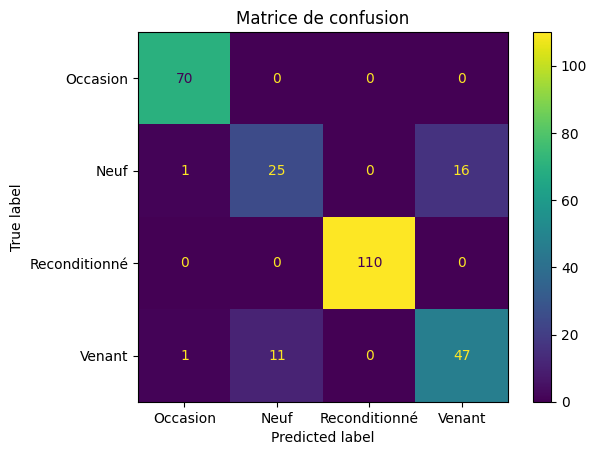

In [53]:
# visualiser
heatmap_conf_matr(rf_model)

In [55]:
# barplot de l'importance des variables
def barplot_impo(rf_model):
    fig = px.bar(x=df.columns[:-1], y=rf_model.feature_importances_, color = df.columns[:-1], text_auto=True)
    fig.show()


In [56]:
# faire appel de la fonction barplot_impo
barplot_impo(rf_model)

### <font color = 'teal'>Gradient Boosting<font>

In [ ]:
# Recherche des paramètres optimaux pour Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# dictionnaire des params
params_ = { "n_estimators":list(np.arange(10,100,10)),
              "max_depth":list(np.arange(3,15))}
# instantier le modèle Gradient Boost
gb = GradientBoostingClassifier()
# instantier le modèle gridsearch
grid_ = GridSearchCV(estimator=gb, param_grid=params_)
# entrainer le modèle
grid_.fit(x_train, y_train)

In [ ]:
# afficher les paramètres optimaux
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(**grid_.best_params_)

In [62]:
# Entrainer Gradient Boosting en utilisant les paramètres optimaux max_depth = 5, n_estimators = 50
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(max_depth = 5, n_estimators = 50)
gb_model.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=50)

##### <font color ='bisque'>Evaluation du Gradient Boosting<font>

In [63]:
# Accuracy et F1 score du modèle sur les données de validation
acc_gb, f1_gb, prec_gb, rec_gb = evaluation(gb_model)
print(f"Accuracy : {acc_gb:.2f}-- F1 score : {f1_gb:.2f} -- Precision : {prec_gb:.2f} -- Recall : {rec_gb:.2f}")

Accuracy : 0.91-- F1 score : 0.91 -- Precision : 0.91 -- Recall : 0.91


In [64]:
# Accuracy sur les données train
y_pred_train = gb_model.predict(x_train)
print(f"Le f1 score est : {f1_score(y_pred_train, y_train, average = 'micro'): .2f}")

Le f1 score est :  0.93


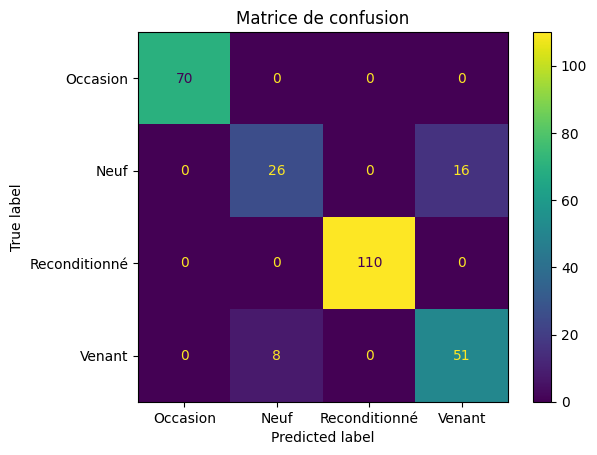

In [65]:
# matrice de confusion
heatmap_conf_matr(gb_model)

In [66]:
# barplot de l'importance des variables
barplot_impo(gb_model)


### <font color = 'teal'>XGBoost<font>

In [67]:
# Recherche des paramètres optimaux pour XGBoost
from xgboost import XGBClassifier
# dictionnaire des params
params__ = {  "n_estimators":list(np.arange(10,100,10)),
              "max_depth":list(np.arange(3,15))}
# instantier le modèle XGBoost
xgb = XGBClassifier()
# instantier le modèle gridsearch
grid__ = GridSearchCV(estimator=xgb, param_grid=params__, cv= 5)
# entrainer le modèle
grid__.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None...
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [68]:
# afficher les paramètres optimaux
params = grid__.best_params_

In [69]:
# Entrainer le modèle en utilisant les paramètres optimaux
xgb_model = XGBClassifier(**params)
xgb_model.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None,
              max_depth=np.int64(5), max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(20), n_jobs=None, num_parallel_tree=None, ...)

##### <font color ='bisque'>Evaluation de XGBoost<font>

In [70]:
# Accuracy et F1 score du modèle sur les données de validation
acc_xgb, f1_xgb, prec_xgb, rec_xgb = evaluation(xgb_model)
print(f"Accuracy : {acc_xgb:.2f}-- F1 score : {f1_xgb:.2f} -- Precision : {prec_xgb:.2f} -- Recall : {rec_xgb:.2f}")


Accuracy : 0.91-- F1 score : 0.91 -- Precision : 0.91 -- Recall : 0.91


In [71]:
# Accuracy sur les données train
y_pred_train = xgb_model.predict(x_train)
print(f"Le f1 score est : {f1_score(y_pred_train, y_train, average = 'micro'): .2f}")


Le f1 score est :  0.91


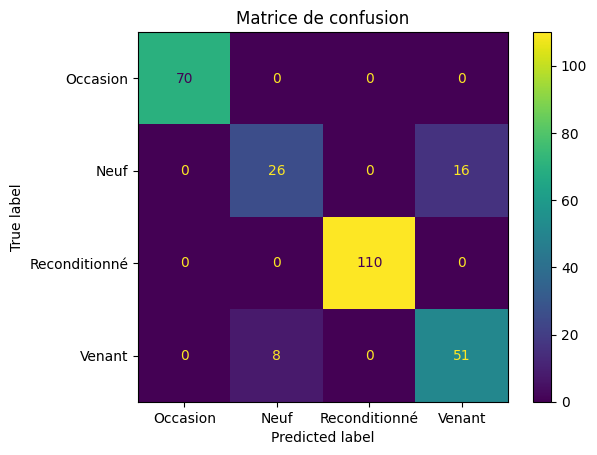

In [72]:
# matrice de confusion
heatmap_conf_matr(gb_model)

In [73]:
# barplot de l'importance des variables
barplot_impo(xgb_model)

In [74]:
# Diagramme en barre de comparaison des modèles
list_f1 = [f1_rf, f1_gb, f1_xgb]
list_models_name = ['RF', 'GB', 'XGB']
fig = px.bar(x=list_models_name, y=list_f1, color = list_models_name, text_auto=True)
fig.show()

In [75]:
# télécharger le modèle le plus performant
jb.dump(xgb_model, '/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/xgb_model.joblib') 

['/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/xgb_model.joblib']

### <font color ='bisque'>Tester le modèle le plus performant<font>

In [80]:
#chantilon de 10 
x_test_10 = x_test[:10]
y_test_10 = y_test[:10]
y_pred_10 = xgb_model.predict(x_test_10)
class_names = ['Ocassion','Neuf', 'Reconditionné','Venant']
for i in range(10):
  print(f"Le téléphone {i+1} est : {class_names[y_pred_10[i]]} | Vrai : {class_names[y_test_10[i]]}")

Le téléphone 1 est : Venant | Vrai : Venant
Le téléphone 2 est : Ocassion | Vrai : Ocassion
Le téléphone 3 est : Ocassion | Vrai : Ocassion
Le téléphone 4 est : Ocassion | Vrai : Ocassion
Le téléphone 5 est : Reconditionné | Vrai : Reconditionné
Le téléphone 6 est : Reconditionné | Vrai : Reconditionné
Le téléphone 7 est : Reconditionné | Vrai : Reconditionné
Le téléphone 8 est : Venant | Vrai : Venant
Le téléphone 9 est : Ocassion | Vrai : Ocassion
Le téléphone 10 est : Venant | Vrai : Venant


### <font color = 'bisque'>Deploiement du modèle avec Gradio<font>

In [4]:
!pip install gradio

In [ ]:
# Fonction de prédiction
import gradio as gr
import joblib as jb
import numpy as np
import pandas as pd
# importer les encodeurs
encoders = jb.load('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/encoders.joblib')
# importer les valeurs uniques
uniques = jb.load('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/uniques.joblib')
# importer le normaliseur
scaler = jb.load('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/scaler.joblib')
# importer le modèle
xgb = jb.load('/content/drive/MyDrive/karaguaIA/Supervised Learning /Classification/xgb_model.joblib')

# noms des classes
clasnames = uniques[2]
# fonction de prédiction simple
def Pred_func(prix, adresse, marque,dim_ecr, ram, stockage):

  # Encoder les valeurs des Fuel_Type, Seller_Type et Transmission
  adresse = encoders[0].transform([adresse])[0]
  marque = encoders[1].transform([marque])[0]
  # vecteur des valeurs numériques
  x_new = np.array([prix, adresse, marque,dim_ecr, ram, stockage])
  x_new = x_new.reshape(1,-1) # convert en un 2D array
  # Normaliser les données
  x_new = scaler.transform(x_new)
  # Prédire
  y_pred = xgb.predict(x_new)
  return clasnames[y_pred[0]]

In [6]:
# Fonction de prédiction multiple
def Pred_func_csv(file):
  # Lire le fichier csv
  df = pd.read_csv(file)
  predictions = []
  # Boucle sur les lignes du dataframe
  for row in df.iloc[:, :].values:
    # prédiction simple
    y_pred = Pred_func(row[0], row[1], row[2], row[3], row[4], row[5])
    predictions.append(y_pred)

  df['etat'] = predictions
  df.to_csv('predictions.csv', index = False)
  return 'predictions.csv'

In [ ]:
# définir les blocks
demo = gr.Blocks(theme='shivi/calm_seafoam')

# Créer les inputs
inputs = [gr.Number(label='Prix'),
          gr.Dropdown(choices=uniques[0], label='Adresse'),
          gr.Dropdown(choices=uniques[1], label='Marque'),
          gr.Number(label='Dimensin écran'),
          gr.Number(label='Nombre de ram'),
          gr.Number(label = 'Stockage')]
# Créer les outputs
outputs = gr.Textbox(label='Etat du portable')
# Créer l'interface 1
interface1 = gr.Interface(fn = Pred_func,
                         inputs = inputs,
                         outputs = outputs,
                         title="Prédire l'état d'un portable avec une entrée",
                         description = """Ce modèle de machine permet de prédire l'état d'un portable en partant
                        du prix, l'adresse, la marque, la dimension de l'écran, le nombre de ram et le stockage.
                         """)
# Créer l'interface 2
interface2 = gr.Interface(fn = Pred_func_csv,
                         inputs = gr.File(label='Importer un fichier csv'),
                          outputs = gr.File(label='Télécharger un fichier csv'),
                         title="Prédire l'état d'un portable avec plusieurs entrées",
                         description = """Ce modèle de machine permet de prédire l'état d'un portable en partant
                        du prix, l'adresse, la marque, la dimension de l'écran, le nombre de ram et le stockage.
                         """)

# faire un tabbing des interfaces
with demo:
  gr.TabbedInterface([interface1, interface2], ['Simple Prediction', 'Prédiction multiple'])

# lancer l'interface
demo.launch(share=True)


theme_schema%400.0.1.json:   0%|          | 0.00/13.0k [00:00<?, ?B/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://13338baf7c9616c247.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
